- Embeddings of words to associate similar 
- --- one_hot encoding gives ints, not floats
- Similarity of phrases
- Example using 3 words to predict the 4th
- Look up table for words and then hidden layers

In [13]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
import random
%matplotlib inline

# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(f'Num of words: {len(words)}')
print(f'Examples: {words[:4]}')

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

Num of words: 32033
Examples: ['emma', 'olivia', 'ava', 'isabella']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# create the corresponding func
def build_dataset(words):  
  block_size = 3
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
### PIPELINE: from dataset to loss
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  #print(w)
  
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)
# X.shape, X.dtype, Y.shape, Y.dtype
print(f'{X.shape = }, {Y.shape = }')

# embedding X
C = torch.randn((27, 2))
emb = C[X]
print(f'{emb.shape = }')

#layer1
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
print(f'{h.shape = }')

#layer2
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
logits = h @ W2 + b2
print(f'{logits.shape = }')

counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
print(f'{prob.shape = }')
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
print(f'{loss = }')

#to avoid re-inventing the wheel:
F.cross_entropy(logits, Y)

X.shape = torch.Size([228146, 3]), Y.shape = torch.Size([228146])
emb.shape = torch.Size([228146, 3, 2])
h.shape = torch.Size([228146, 100])
logits.shape = torch.Size([228146, 27])
prob.shape = torch.Size([228146, 27])
loss = tensor(17.0745)


tensor(17.0745)

In [58]:
# All parameters
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 400), generator=g)
b1 = torch.randn(400, generator=g)
W2 = torch.randn((400, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

sum(p.nelement() for p in parameters) # number of parameters in total

23497

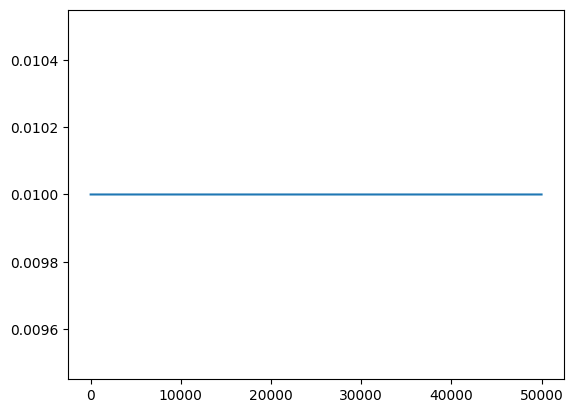

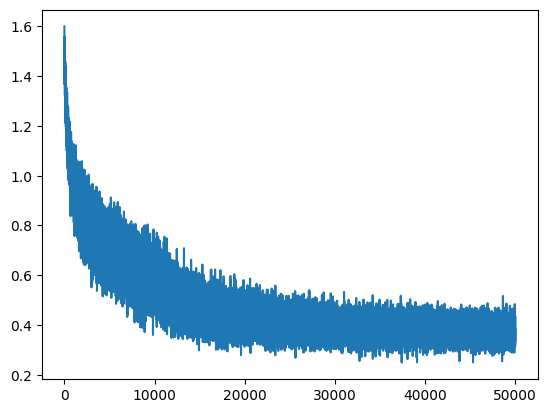

In [59]:
epochs = 50000

init_lr = 0.1
end_lr = 0.01
step_switch_lr = epochs/4

use_exp_lr = False
lre = torch.linspace(0.5, -5, epochs)
lrs = 10**lre


lr_i = []
loss_i = []
# step_i = []

for i in range(epochs):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (64,)) 
  # avoid overfitting: approx gradient (lower quality), but good enoigh to be useful
  # alternative: less steps with exact gradient, but sometimes unfeasible and sometimes slower
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  if use_exp_lr:
    lr = lrs[i]
    # pass
  else:
    lr = init_lr if i < step_switch_lr else end_lr
    lr = end_lr

  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lr_i.append(lr)
#   step_i.append(i)
  loss_i.append(loss.log10().item())

# plot lrs agains losses to find sweet spots for lr to use

if use_exp_lr:
  plt.plot(lr_i, loss_i)
  plt.show()
# plot of the lr progression
plt.plot(lr_i)
plt.show()
# plot of the loss progression
plt.plot(loss_i)
plt.show()

In [61]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3964, grad_fn=<NllLossBackward0>)

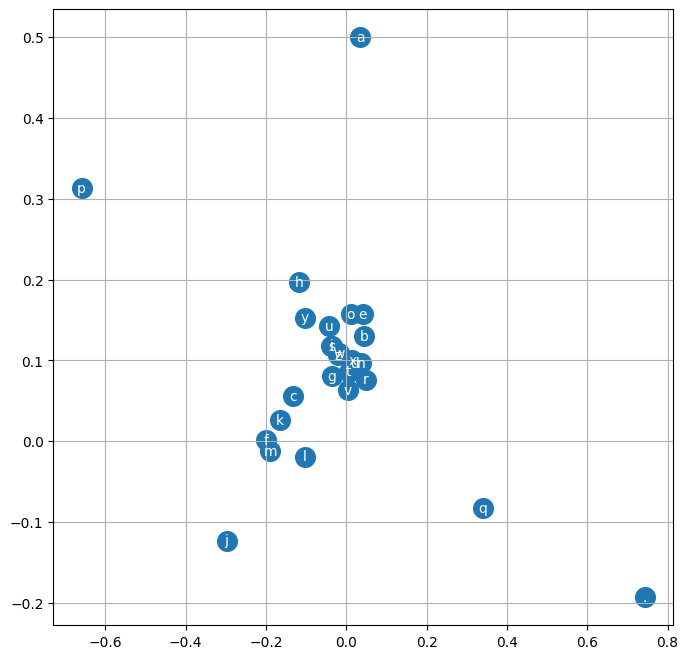

In [60]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
context = [0] * block_size
C[torch.tensor([context])].shape

In [39]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)
num_names = 10

for _ in range(num_names):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))


carmah.
ami.
harih.
jarli.
taty.
skahon.
emmahuen.
deliah.
jareen.
nermara.
